In [ ]:
# Importing necessary libraries for data manipulation and visualization
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
np.random.seed(0) # We need to generate same random numbers every time we run the code, so that we can compare our results with the expected results.

In [ ]:
# Dogs: Lower whisker length, higher ear flappiness index
dogs_whisker_length = np.random.normal(loc = 5, scale = 1, size = 10)
dogs_ear_flappiness_index = np.random.normal(loc = 8, scale = 1, size = 10)

In [ ]:
print(dogs_whisker_length)
print(dogs_ear_flappiness_index)

[6.76405235 5.40015721 5.97873798 7.2408932  6.86755799 4.02272212
 5.95008842 4.84864279 4.89678115 5.4105985 ]
[8.14404357 9.45427351 8.76103773 8.12167502 8.44386323 8.33367433
 9.49407907 7.79484174 8.3130677  7.14590426]


In [ ]:
# Cats: Higher whisker length, lower ear flappiness index
cats_whisker_length = np.random.normal(loc = 8, scale = 1, size = 10)
cats_ear_flappiness_index = np.random.normal(loc = 5, scale = 1, size = 10)

In [ ]:
print(cats_whisker_length)
print(cats_ear_flappiness_index)

[ 5.44701018  8.6536186   8.8644362   7.25783498 10.26975462  6.54563433
  8.04575852  7.81281615  9.53277921  9.46935877]
[5.15494743 5.37816252 4.11221425 3.01920353 4.65208785 5.15634897
 6.23029068 6.20237985 4.61267318 4.69769725]


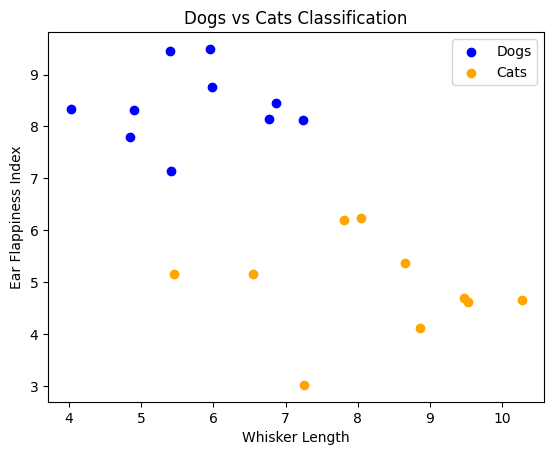

In [ ]:
plt.scatter(dogs_whisker_length, dogs_ear_flappiness_index, color = 'blue', label = 'Dogs')
plt.scatter(cats_whisker_length, cats_ear_flappiness_index, color = 'orange', label = 'Cats')
plt.xlabel('Whisker Length')
plt.ylabel('Ear Flappiness Index')
plt.title('Dogs vs Cats Classification')
plt.legend()
plt.show()

In [ ]:
# Linear Classifier
# d = Number of features (2 in our case - whisker length and ear flappiness index)
# k = Number of random linear classifiers we want to generate
def linear_classifier(data_dogs, data_cats, k, d):
    best_error = float('inf')
    best_theta = None
    best_theta0 = None

    for _ in range(k):
        theta = np.random.normal(0, 1, d)
        theta0 = np.random.normal(0, 1)

        error = compute_error(data_dogs, data_cats, theta, theta0)

        if error < best_error:
            best_error = error
            best_theta = theta
            best_theta0 = theta0

    return best_theta, best_theta0

In [ ]:
def compute_error(data_dogs, data_cats, theta, theta0):
    error = 0

    for x_dog in data_dogs:
        if np.dot(theta, x_dog) + theta0 <= 0:
            error += 1

    for x_cat in data_cats:
        if np.dot(theta, x_cat) + theta0 > 0:
            error += 1

    return error

In [ ]:
dogs_data = np.vstack((dogs_whisker_length, dogs_ear_flappiness_index)).T
cats_data = np.vstack((cats_whisker_length, cats_ear_flappiness_index)).T

In [ ]:
print("Dogs Data:\n", dogs_data)
print("Cats Data:\n", cats_data)

Dogs Data:
 [[6.76405235 8.14404357]
 [5.40015721 9.45427351]
 [5.97873798 8.76103773]
 [7.2408932  8.12167502]
 [6.86755799 8.44386323]
 [4.02272212 8.33367433]
 [5.95008842 9.49407907]
 [4.84864279 7.79484174]
 [4.89678115 8.3130677 ]
 [5.4105985  7.14590426]]
Cats Data:
 [[ 5.44701018  5.15494743]
 [ 8.6536186   5.37816252]
 [ 8.8644362   4.11221425]
 [ 7.25783498  3.01920353]
 [10.26975462  4.65208785]
 [ 6.54563433  5.15634897]
 [ 8.04575852  6.23029068]
 [ 7.81281615  6.20237985]
 [ 9.53277921  4.61267318]
 [ 9.46935877  4.69769725]]


In [ ]:
k = 100
d = 2
best_theta, best_theta0 = linear_classifier(dogs_data, cats_data, k, d)
print("Best Theta:", best_theta)
print("Best Theta0:", best_theta0)

Best Theta: [-1.07075262  1.05445173]
Best Theta0: -0.40317694697317963


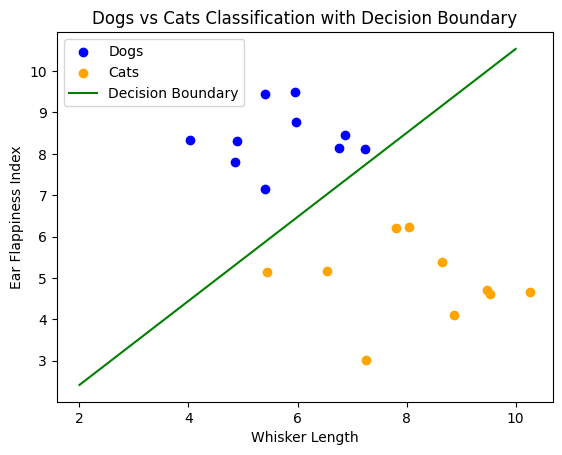

In [ ]:
# Plot the decision boundary
x_values = np.linspace(2, 10, 100)
y_values = -(best_theta[0] * x_values + best_theta0) / best_theta[1]
plt.scatter(dogs_whisker_length, dogs_ear_flappiness_index, color = 'blue', label = 'Dogs')
plt.scatter(cats_whisker_length, cats_ear_flappiness_index, color = 'orange', label = 'Cats')
plt.plot(x_values, y_values, color = 'green', label = 'Decision Boundary')
plt.xlabel('Whisker Length')
plt.ylabel('Ear Flappiness Index')
plt.title('Dogs vs Cats Classification with Decision Boundary')
plt.legend()
plt.show()